<a href="https://colab.research.google.com/github/Rasmy-r7/Research/blob/main/TinyBERT%26CodeBERT_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 1: Install required packages
# Run this first, then restart runtime
#═══════════════════════════════════════════════════════════════
import os
os.environ["WANDB_DISABLED"] = "true"

!pip uninstall transformers accelerate peft sentence-transformers -y -q
!pip install transformers==4.41.0 accelerate==0.27.2 -q
!pip install sentence-transformers -q

print("✅ Installation complete!")
print("   → Runtime → Restart Session → OK")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 40.3 MB/s eta 0:00:00
✅ Installation complete!
   → Runtime → Restart Session → OK


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 2: Import all libraries
# Run immediately after restarting runtime
#═══════════════════════════════════════════════════════════════
import os, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    get_cosine_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm

os.environ["WANDB_DISABLED"] = "true"

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ All libraries imported!")
print(f"   Device : {device}")
if not torch.cuda.is_available():
    print("   ⚠️  No GPU! → Runtime → Change Runtime Type → T4 GPU")

✅ All libraries imported!
   Device : cuda


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 3: Upload and load all 3 CSV files
# Required columns: text, priority, priority_id
#═══════════════════════════════════════════════════════════════
from google.colab import files

print("Upload your 3 CSV files:")
print("   1. train_combined.csv")
print("   2. val_combined.csv")
print("   3. test_combined.csv")

uploaded = files.upload()

train_df = pd.read_csv("train_combined.csv")
val_df   = pd.read_csv("val_combined.csv")
test_df  = pd.read_csv("test_combined.csv")

# ── Validate columns ─────────────────────────────────────────
for name, df in [("train", train_df),
                 ("val",   val_df),
                 ("test",  test_df)]:
    assert 'text'        in df.columns, f"❌ Missing 'text' in {name}"
    assert 'priority_id' in df.columns, f"❌ Missing 'priority_id' in {name}"
    assert 'priority'    in df.columns, f"❌ Missing 'priority' in {name}"

# ── Label config ─────────────────────────────────────────────
LABEL_MAP   = {'High': 0, 'Medium': 1, 'Low': 2}
INV_LABEL   = {0: 'High', 1: 'Medium', 2: 'Low'}
NUM_CLASSES = 3

for df in [train_df, val_df, test_df]:
    df['priority_id'] = df['priority_id'].astype(int)

print(f"\n✅ All files loaded!")
print(f"   Train : {len(train_df):,} rows")
print(f"   Val   : {len(val_df):,} rows")
print(f"   Test  : {len(test_df):,} rows")
print(f"\n   Label distribution (train):")
print(train_df['priority'].value_counts().to_string())

Upload your 3 CSV files:
   1. train_combined.csv
   2. val_combined.csv
   3. test_combined.csv


Saving test_combined.csv to test_combined.csv
Saving val_combined.csv to val_combined.csv
Saving train_combined.csv to train_combined.csv

✅ All files loaded!
   Train : 23,274 rows
   Val   : 2,909 rows
   Test  : 2,910 rows

   Label distribution (train):
priority
Medium    9430
High      8550
Low       5294


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 4: Load TinyBERT + CodeBERT
# ANTI-OVERFIT: Unfreeze FEWER layers
#   TinyBERT : ONLY layer 3 + pooler  (was layers 1,2,3)
#   CodeBERT : ONLY layers 10,11 + pooler  (was 8,9,10,11)
# Less capacity → less memorization
#═══════════════════════════════════════════════════════════════
TINYBERT_NAME = "huawei-noah/TinyBERT_General_4L_312D"
CODEBERT_NAME = "microsoft/codebert-base"

print("Loading TinyBERT...")
tinybert_tokenizer = AutoTokenizer.from_pretrained(TINYBERT_NAME)
tinybert_model     = AutoModel.from_pretrained(TINYBERT_NAME).to(device)

print("Loading CodeBERT...")
codebert_tokenizer = AutoTokenizer.from_pretrained(CODEBERT_NAME)
codebert_model     = AutoModel.from_pretrained(CODEBERT_NAME).to(device)

# ── Freeze all layers first ──────────────────────────────────
for m in [tinybert_model, codebert_model]:
    for param in m.parameters():
        param.requires_grad = False

# ── Unfreeze ONLY last layer of TinyBERT + pooler ───────────
for name, param in tinybert_model.named_parameters():
    if "layer.3" in name:
        param.requires_grad = True
    if 'pooler' in name:
        param.requires_grad = True

# ── Unfreeze ONLY last 2 layers of CodeBERT + pooler ────────
for name, param in codebert_model.named_parameters():
    if any(f"layer.{i}" in name for i in [10, 11]):
        param.requires_grad = True
    if 'pooler' in name:
        param.requires_grad = True

# ── Embedding dimensions ─────────────────────────────────────
TINYBERT_DIM = 312
CODEBERT_DIM = 768
FUSED_DIM    = TINYBERT_DIM + CODEBERT_DIM   # 1080

tiny_trainable = sum(p.numel() for p in tinybert_model.parameters()
                     if p.requires_grad)
code_trainable = sum(p.numel() for p in codebert_model.parameters()
                     if p.requires_grad)

print(f"\n✅ Both models loaded!")
print(f"   TinyBERT trainable : {tiny_trainable:,} params (layer 3 + pooler)")
print(f"   CodeBERT trainable : {code_trainable:,} params (layers 10-11 + pooler)")
print(f"   Fused dim          : {FUSED_DIM}")

Loading TinyBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]


✅ Both models loaded!
   TinyBERT trainable : 1,239,840 params (layer 3 + pooler)
   CodeBERT trainable : 14,766,336 params (layers 10-11 + pooler)
   Fused dim          : 1080


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 5: FusionDataset
# Tokenizes each text TWICE:
#   → TinyBERT tokenizer
#   → CodeBERT tokenizer
#═══════════════════════════════════════════════════════════════
MAX_LENGTH = 128
BATCH_SIZE = 16

class FusionDataset(Dataset):
    def __init__(self, dataframe, tiny_tokenizer,
                 code_tokenizer, max_length=MAX_LENGTH):
        self.texts          = dataframe['text'].tolist()
        self.labels         = dataframe['priority_id'].tolist()
        self.tiny_tokenizer = tiny_tokenizer
        self.code_tokenizer = code_tokenizer
        self.max_length     = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        tiny_enc = self.tiny_tokenizer(
            text,
            max_length     = self.max_length,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        code_enc = self.code_tokenizer(
            text,
            max_length     = self.max_length,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )

        return {
            'tiny_input_ids'     : tiny_enc['input_ids'].squeeze(0),
            'tiny_attention_mask': tiny_enc['attention_mask'].squeeze(0),
            'code_input_ids'     : code_enc['input_ids'].squeeze(0),
            'code_attention_mask': code_enc['attention_mask'].squeeze(0),
            'label'              : torch.tensor(
                                       self.labels[idx], dtype=torch.long
                                   )
        }

train_dataset = FusionDataset(train_df, tinybert_tokenizer, codebert_tokenizer)
val_dataset   = FusionDataset(val_df,   tinybert_tokenizer, codebert_tokenizer)
test_dataset  = FusionDataset(test_df,  tinybert_tokenizer, codebert_tokenizer)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=64,
                           shuffle=False, num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=64,
                           shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Datasets and DataLoaders ready!")
print(f"   Train : {len(train_dataset):,} samples | {len(train_loader)} batches")
print(f"   Val   : {len(val_dataset):,} samples | {len(val_loader)} batches")
print(f"   Test  : {len(test_dataset):,} samples | {len(test_loader)} batches")
print(f"   Batch size : {BATCH_SIZE} | Max length : {MAX_LENGTH}")

✅ Datasets and DataLoaders ready!
   Train : 23,274 samples | 1455 batches
   Val   : 2,909 samples | 46 batches
   Test  : 2,910 samples | 46 batches
   Batch size : 16 | Max length : 128


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 6: Fusion Classifier
# ANTI-OVERFIT: Increased dropout at every layer
#   Projection dropout : 0.2 → 0.3
#   dropout1/2/3       : 0.4/0.3/0.2 → 0.5/0.4/0.3
#═══════════════════════════════════════════════════════════════
class TinyBERTCodeBERTFusionClassifier(nn.Module):
    def __init__(self, tiny_dim=312, code_dim=768,
                 num_classes=3,
                 dropout1=0.5, dropout2=0.4, dropout3=0.3):
        super().__init__()

        # ── Projection layers (higher dropout) ──────────────
        self.tiny_proj = nn.Sequential(
            nn.Linear(tiny_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3)        # was 0.2
        )
        self.code_proj = nn.Sequential(
            nn.Linear(code_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3)        # was 0.2
        )

        # 256 + 512 = 768
        proj_dim = 256 + 512

        # ── Residual ─────────────────────────────────────────
        self.residual_proj = nn.Linear(proj_dim, 512)

        # ── Classifier layers ─────────────────────────────────
        self.fc1   = nn.Linear(proj_dim, 512)
        self.norm1 = nn.LayerNorm(512)
        self.drop1 = nn.Dropout(dropout1)

        self.fc2   = nn.Linear(512, 256)
        self.norm2 = nn.LayerNorm(256)
        self.drop2 = nn.Dropout(dropout2)

        self.fc3   = nn.Linear(256, 128)
        self.norm3 = nn.LayerNorm(128)
        self.drop3 = nn.Dropout(dropout3)

        self.fc4   = nn.Linear(128, num_classes)

        self.activation = nn.GELU()
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, tiny_emb, code_emb):
        # Project each independently
        tiny_out = self.tiny_proj(tiny_emb)                   # (B, 256)
        code_out = self.code_proj(code_emb)                   # (B, 512)

        # Concatenate
        fused    = torch.cat([tiny_out, code_out], dim=-1)    # (B, 768)

        # Layer 1 + residual
        residual = self.residual_proj(fused)                  # (B, 512)
        x        = self.activation(self.norm1(self.fc1(fused)))
        x        = self.drop1(x + residual)

        # Layer 2
        x        = self.activation(self.norm2(self.fc2(x)))
        x        = self.drop2(x)

        # Layer 3
        x        = self.activation(self.norm3(self.fc3(x)))
        x        = self.drop3(x)

        # Output
        return self.fc4(x)


classifier = TinyBERTCodeBERTFusionClassifier(
    tiny_dim    = TINYBERT_DIM,
    code_dim    = CODEBERT_DIM,
    num_classes = NUM_CLASSES,
    dropout1    = 0.5,   # was 0.4
    dropout2    = 0.4,   # was 0.3
    dropout3    = 0.3,   # was 0.2
).to(device)

total_params     = sum(p.numel() for p in classifier.parameters())
trainable_params = sum(p.numel() for p in classifier.parameters()
                       if p.requires_grad)

print("✅ Fusion Classifier built (anti-overfit dropout)!")
print(f"   TinyBERT({TINYBERT_DIM}) → proj(256)")
print(f"   CodeBERT({CODEBERT_DIM}) → proj(512)")
print(f"   Concat(768) → 512 → 256 → 128 → {NUM_CLASSES}")
print(f"   Dropout      : 0.5 / 0.4 / 0.3  (projection 0.3)")
print(f"   Total params     : {total_params:,}")
print(f"   Trainable params : {trainable_params:,}")

✅ Fusion Classifier built (anti-overfit dropout)!
   TinyBERT(312) → proj(256)
   CodeBERT(768) → proj(512)
   Concat(768) → 512 → 256 → 128 → 3
   Dropout      : 0.5 / 0.4 / 0.3  (projection 0.3)
   Total params     : 1,429,251
   Trainable params : 1,429,251


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 7: Anti-overfit training configuration
#   Backbone LR  : 5e-5 → 1e-5
#   Head LR      : 3e-4 → 1e-4
#   Weight decay : 0.01 → 0.05
#   Focal gamma  : 3.0 → 2.0
#   Label smooth : 0.05 → 0.1
#   Medium boost : x1.8 → x1.5
#   Epochs       : 30 → 15
#   Warmup ratio : 6% → 10%
#═══════════════════════════════════════════════════════════════

# ── Class weights (gentler Medium boost) ─────────────────────
raw_weights    = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array([0, 1, 2]),
    y            = train_df['priority_id'].values
)
raw_weights[1] = raw_weights[1] * 1.5    # reduced from 1.8
class_weights  = torch.tensor(raw_weights, dtype=torch.float).to(device)

print("Class weights:")
print(f"   High   (0) : {raw_weights[0]:.4f}")
print(f"   Medium (1) : {raw_weights[1]:.4f}  ← boosted x1.5")
print(f"   Low    (2) : {raw_weights[2]:.4f}")

# ── Focal Loss — gentler settings ────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, labels):
        ce    = F.cross_entropy(
                    logits, labels,
                    weight          = self.weight,
                    label_smoothing = self.label_smoothing,
                    reduction       = 'none'
                )
        pt    = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()

criterion = FocalLoss(
    weight          = class_weights,
    gamma           = 2.0,    # reduced from 3.0
    label_smoothing = 0.1     # increased from 0.05
)

# ── Lower LR + higher weight decay + fewer epochs ────────────
EPOCHS       = 15        # reduced from 30
BACKBONE_LR  = 1e-5       # reduced from 5e-5
HEAD_LR      = 1e-4       # reduced from 3e-4
WEIGHT_DECAY = 0.05       # increased from 0.01

optimizer = torch.optim.AdamW([
    {'params': [p for p in tinybert_model.parameters()
                if p.requires_grad],
     'lr': BACKBONE_LR},
    {'params': [p for p in codebert_model.parameters()
                if p.requires_grad],
     'lr': BACKBONE_LR},
    {'params': classifier.parameters(),
     'lr': HEAD_LR},
], weight_decay=WEIGHT_DECAY)

# ── Cosine LR with warmup ────────────────────────────────────
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)   # back to 10%

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f"\n✅ Anti-overfit training config ready!")
print(f"   Backbone LR  : {BACKBONE_LR}  (was 5e-5)")
print(f"   Head LR      : {HEAD_LR}  (was 3e-4)")
print(f"   Weight decay : {WEIGHT_DECAY}  (was 0.01)")
print(f"   Focal gamma  : 2.0  (was 3.0)")
print(f"   Label smooth : 0.1  (was 0.05)")
print(f"   Epochs       : {EPOCHS}  (was 30)")
print(f"   Warmup steps : {warmup_steps}  (10%)")

Class weights:
   High   (0) : 0.9074
   Medium (1) : 1.2340  ← boosted x1.5
   Low    (2) : 1.4654

✅ Anti-overfit training config ready!
   Backbone LR  : 1e-05  (was 5e-5)
   Head LR      : 0.0001  (was 3e-4)
   Weight decay : 0.05  (was 0.01)
   Focal gamma  : 2.0  (was 3.0)
   Label smooth : 0.1  (was 0.05)
   Epochs       : 15  (was 30)
   Warmup steps : 2182  (10%)


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 8: Embedding extraction
# training=True  → gradients through unfrozen backbone layers
# training=False → no_grad for validation and inference
#═══════════════════════════════════════════════════════════════
def extract_embeddings(batch, training=False):
    tiny_ids  = batch['tiny_input_ids'].to(device)
    tiny_mask = batch['tiny_attention_mask'].to(device)
    code_ids  = batch['code_input_ids'].to(device)
    code_mask = batch['code_attention_mask'].to(device)

    if training:
        tiny_emb = tinybert_model(
            input_ids      = tiny_ids,
            attention_mask = tiny_mask
        ).last_hidden_state[:, 0, :]

        code_emb = codebert_model(
            input_ids      = code_ids,
            attention_mask = code_mask
        ).last_hidden_state[:, 0, :]
    else:
        with torch.no_grad():
            tiny_emb = tinybert_model(
                input_ids      = tiny_ids,
                attention_mask = tiny_mask
            ).last_hidden_state[:, 0, :]

            code_emb = codebert_model(
                input_ids      = code_ids,
                attention_mask = code_mask
            ).last_hidden_state[:, 0, :]

    return tiny_emb, code_emb

print("✅ Embedding extraction ready!")
print("   training=True  → gradients through unfrozen layers")
print("   training=False → no_grad for val/inference")

✅ Embedding extraction ready!
   training=True  → gradients through unfrozen layers
   training=False → no_grad for val/inference


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 9: Training loop
# ANTI-OVERFIT changes:
#   Track BEST VAL LOSS (not just macro F1) for checkpoint
#   Conditional scheduler.step() — fixes UserWarning
#   PATIENCE reduced 7 → 5
# ~25-30 min on T4 GPU (15 epochs)
#═══════════════════════════════════════════════════════════════
PATIENCE = 5   # reduced from 7

history = {
    'train_loss': [], 'val_loss'  : [],
    'train_acc' : [], 'val_acc'   : [],
    'val_macro' : []
}

best_val_loss  = float('inf')   # NEW — track lowest val loss
best_val_macro = 0.0
best_state     = None
patience_count = 0

scaler = torch.amp.GradScaler('cuda')

print("=" * 70)
print("   TRAINING : TinyBERT ⊕ CodeBERT  (anti-overfit fine-tuning)")
print("=" * 70)
print(f"{'Epoch':>6} {'TrLoss':>9} {'VlLoss':>9} "
      f"{'TrAcc':>8} {'VlAcc':>8} {'MacroF1':>9}")
print("-" * 70)

for epoch in range(EPOCHS):

    # ── TRAIN ────────────────────────────────────────────────
    classifier.train()
    tinybert_model.train()
    codebert_model.train()

    tr_loss, tr_preds, tr_labels = 0.0, [], []

    for batch in train_loader:
        labels = batch['label'].to(device)

        tiny_emb, code_emb = extract_embeddings(batch, training=True)

        with torch.amp.autocast('cuda'):
            logits = classifier(tiny_emb, code_emb)
            loss   = criterion(logits, labels)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            list(classifier.parameters()) +
            [p for p in tinybert_model.parameters()
             if p.requires_grad] +
            [p for p in codebert_model.parameters()
             if p.requires_grad],
            max_norm = 1.0
        )

        # Conditional scheduler step — fixes UserWarning
        scale_before = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        scale_after = scaler.get_scale()

        if scale_after >= scale_before:
            scheduler.step()

        tr_loss += loss.item()
        tr_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        tr_labels.extend(labels.cpu().numpy())

    avg_tr_loss = tr_loss / len(train_loader)
    tr_acc      = accuracy_score(tr_labels, tr_preds)

    # ── VALIDATE ─────────────────────────────────────────────
    classifier.eval()
    tinybert_model.eval()
    codebert_model.eval()

    vl_loss, vl_preds, vl_labels = 0.0, [], []

    with torch.no_grad():
        for batch in val_loader:
            labels = batch['label'].to(device)

            tiny_emb, code_emb = extract_embeddings(
                batch, training=False
            )

            with torch.amp.autocast('cuda'):
                logits = classifier(tiny_emb, code_emb)
                loss   = criterion(logits, labels)

            vl_loss += loss.item()
            vl_preds.extend(logits.argmax(dim=-1).cpu().numpy())
            vl_labels.extend(labels.cpu().numpy())

    avg_vl_loss = vl_loss / len(val_loader)
    vl_acc      = accuracy_score(vl_labels, vl_preds)
    vl_macro    = f1_score(vl_labels, vl_preds, average='macro')

    history['train_loss'].append(avg_tr_loss)
    history['val_loss'].append(avg_vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_macro'].append(vl_macro)

    # ── Checkpoint on BEST VAL LOSS (not macro F1) ───────────
    flag = ""
    if avg_vl_loss < best_val_loss:
        best_val_loss  = avg_vl_loss
        best_val_macro = vl_macro
        best_state     = {k: v.cpu().clone()
                          for k, v in classifier.state_dict().items()}
        patience_count = 0
        flag           = "  ✅ best"
    else:
        patience_count += 1
        flag            = f"  (patience {patience_count}/{PATIENCE})"

    print(f"{epoch+1:>6} {avg_tr_loss:>9.4f} {avg_vl_loss:>9.4f} "
          f"{tr_acc:>8.4f} {vl_acc:>8.4f} {vl_macro:>9.4f}{flag}")

    if patience_count >= PATIENCE:
        print(f"\n⏹  Early stopping at epoch {epoch+1}")
        break

classifier.load_state_dict(best_state)
classifier.to(device)
print(f"\n✅ Training complete!")
print(f"   Best val loss  : {best_val_loss:.4f}")
print(f"   Best val macro : {best_val_macro:.4f}")

   TRAINING : TinyBERT ⊕ CodeBERT  (anti-overfit fine-tuning)
 Epoch    TrLoss    VlLoss    TrAcc    VlAcc   MacroF1
----------------------------------------------------------------------
     1    0.8043    0.4903   0.4388   0.5390    0.4673  ✅ best
     2    0.4624    0.3956   0.6191   0.6377    0.6420  ✅ best
     3    0.3993    0.3729   0.6765   0.6831    0.6941  ✅ best
     4    0.3721    0.3697   0.6994   0.7243    0.7357  ✅ best
     5    0.3559    0.3561   0.7147   0.7387    0.7482  ✅ best
     6    0.3429    0.3375   0.7261   0.7356    0.7469  ✅ best
     7    0.3331    0.3545   0.7361   0.7353    0.7464  (patience 1/5)
     8    0.3248    0.3456   0.7381   0.7470    0.7575  (patience 2/5)
     9    0.3188    0.3320   0.7456   0.7391    0.7484  ✅ best
    10    0.3121    0.3328   0.7495   0.7460    0.7573  (patience 1/5)
    11    0.3050    0.3421   0.7535   0.7442    0.7534  (patience 2/5)
    12    0.3063    0.3338   0.7571   0.7449    0.7547  (patience 3/5)
    13    0.3004

In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 10: Full evaluation on held-out test set
#═══════════════════════════════════════════════════════════════
classifier.eval()
tinybert_model.eval()
codebert_model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for batch in test_loader:
        labels = batch['label'].to(device)

        tiny_emb, code_emb = extract_embeddings(batch, training=False)

        with torch.amp.autocast('cuda'):
            logits = classifier(tiny_emb, code_emb)

        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = logits.argmax(dim=-1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc         = accuracy_score(all_labels,  all_preds)
precision   = precision_score(all_labels, all_preds, average='macro')
recall      = recall_score(all_labels,    all_preds, average='macro')
macro_f1    = f1_score(all_labels,        all_preds, average='macro')
weighted_f1 = f1_score(all_labels,        all_preds, average='weighted')

print("=" * 65)
print("    FINAL EVALUATION — TinyBERT ⊕ CodeBERT Fusion")
print("=" * 65)
print(f"   Accuracy          : {acc:.4f}")
print(f"   Precision (macro) : {precision:.4f}")
print(f"   Recall    (macro) : {recall:.4f}")
print(f"   F1 Macro          : {macro_f1:.4f}")
print(f"   F1 Weighted       : {weighted_f1:.4f}")
print("=" * 65)

print("\nPer-class Classification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names = ['High', 'Medium', 'Low'],
    digits       = 4
))

cm    = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(
    cm,
    index   = ['Actual High', 'Actual Medium', 'Actual Low'],
    columns = ['Pred High',   'Pred Medium',   'Pred Low']
)
print("Confusion Matrix:")
print(cm_df)

    FINAL EVALUATION — TinyBERT ⊕ CodeBERT Fusion
   Accuracy          : 0.7436
   Precision (macro) : 0.7659
   Recall    (macro) : 0.7478
   F1 Macro          : 0.7547
   F1 Weighted       : 0.7442

Per-class Classification Report:
              precision    recall  f1-score   support

        High     0.7433    0.6745    0.7072      1069
      Medium     0.6891    0.7820    0.7326      1179
         Low     0.8654    0.7870    0.8244       662

    accuracy                         0.7436      2910
   macro avg     0.7659    0.7478    0.7547      2910
weighted avg     0.7491    0.7436    0.7442      2910

Confusion Matrix:
               Pred High  Pred Medium  Pred Low
Actual High          721          319        29
Actual Medium        205          922        52
Actual Low            44           97       521


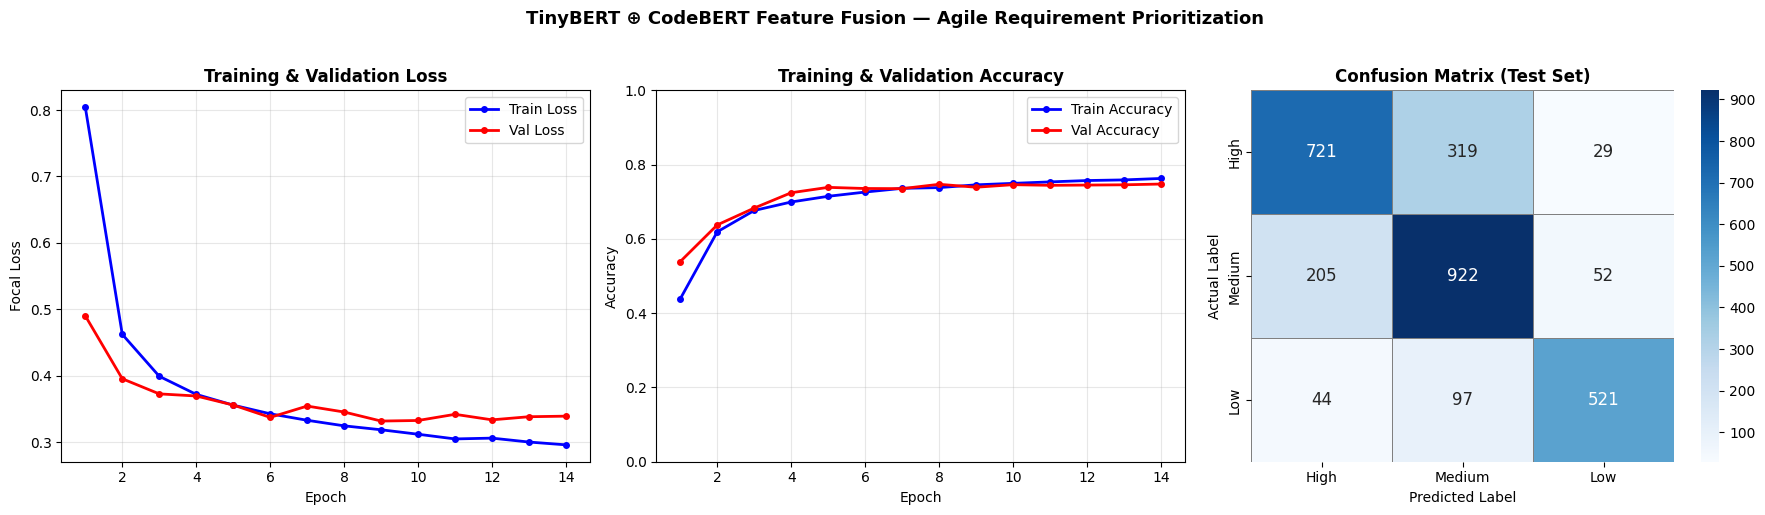

✅ Plots saved → fusion_results.png


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 11: Plot training curves + confusion matrix
#═══════════════════════════════════════════════════════════════
epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)

fig, axes  = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "TinyBERT ⊕ CodeBERT Feature Fusion — Agile Requirement Prioritization",
    fontsize=13, fontweight='bold', y=1.02
)

# ── Loss ─────────────────────────────────────────────────────
axes[0].plot(x, history['train_loss'], 'b-o', markersize=4,
             linewidth=2, label='Train Loss')
axes[0].plot(x, history['val_loss'],   'r-o', markersize=4,
             linewidth=2, label='Val Loss')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Accuracy ─────────────────────────────────────────────────
axes[1].plot(x, history['train_acc'], 'b-o', markersize=4,
             linewidth=2, label='Train Accuracy')
axes[1].plot(x, history['val_acc'],   'r-o', markersize=4,
             linewidth=2, label='Val Accuracy')
axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Confusion Matrix ─────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels = ['High', 'Medium', 'Low'],
    yticklabels = ['High', 'Medium', 'Low'],
    ax          = axes[2],
    linewidths  = 0.5,
    linecolor   = 'gray',
    annot_kws   = {"size": 12}
)
axes[2].set_title('Confusion Matrix (Test Set)', fontweight='bold')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('Actual Label')

plt.tight_layout()
plt.savefig("fusion_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plots saved → fusion_results.png")

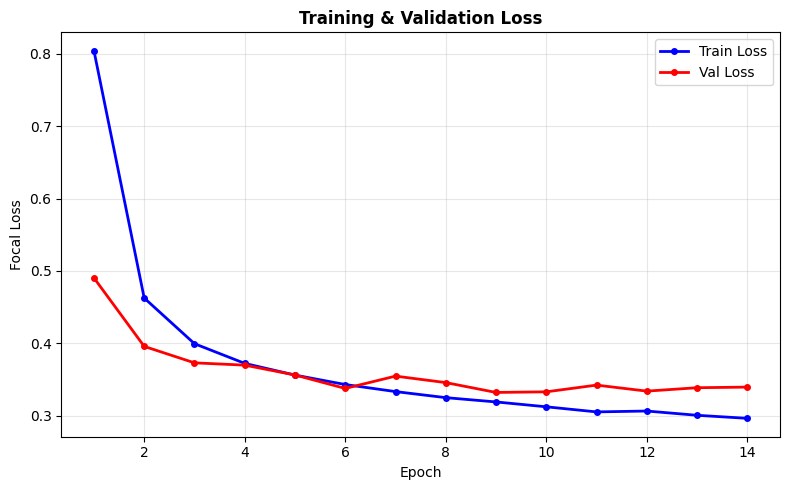

✅ Saved → loss_plot.png


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 11: Plot Loss
#═══════════════════════════════════════════════════════════════
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

plt.figure(figsize=(8, 5))
plt.plot(x, history['train_loss'], 'b-o',
         markersize=4, linewidth=2, label='Train Loss')
plt.plot(x, history['val_loss'], 'r-o',
         markersize=4, linewidth=2, label='Val Loss')

plt.title('Training & Validation Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Focal Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("loss_plot.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved → loss_plot.png")

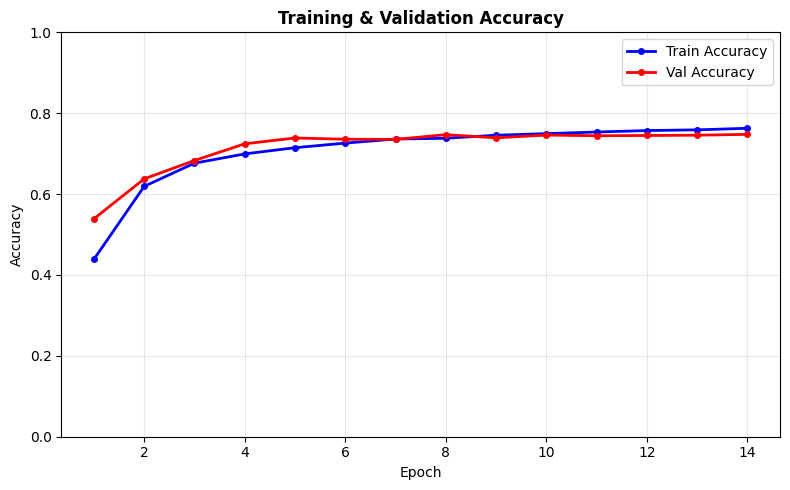

✅ Saved → accuracy_plot.png


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 12: Plot Accuracy
#═══════════════════════════════════════════════════════════════

plt.figure(figsize=(8, 5))
plt.plot(x, history['train_acc'], 'b-o',
         markersize=4, linewidth=2, label='Train Accuracy')
plt.plot(x, history['val_acc'], 'r-o',
         markersize=4, linewidth=2, label='Val Accuracy')

plt.title('Training & Validation Accuracy', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("accuracy_plot.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved → accuracy_plot.png")

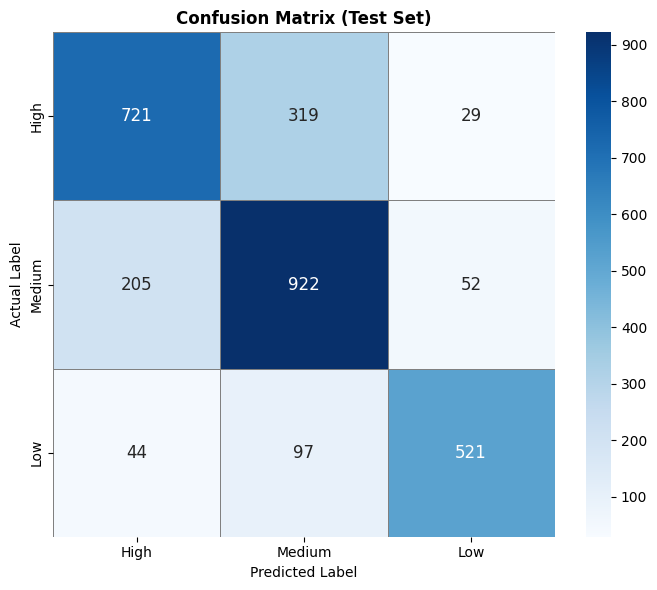

✅ Saved → confusion_matrix.png


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 13: Plot Confusion Matrix
#═══════════════════════════════════════════════════════════════

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['High', 'Medium', 'Low'],
    yticklabels=['High', 'Medium', 'Low'],
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 12}
)

plt.title('Confusion Matrix (Test Set)', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved → confusion_matrix.png")

In [1]:
#═══════════════════════════════════════════════════════════════
# STEP 12: Save model + results to Drive — do immediately!
#═══════════════════════════════════════════════════════════════
import shutil
from google.colab import drive, files as colab_files

drive.mount('/content/drive')
os.makedirs("./fusion_model_v4", exist_ok=True)

# ── Classifier weights ───────────────────────────────────────
torch.save(
    classifier.state_dict(),
    "./fusion_model_v4/classifier_weights.pt"
)

# ── Finetuned backbone weights ───────────────────────────────
torch.save(
    tinybert_model.state_dict(),
    "./fusion_model_v4/tinybert_finetuned.pt"
)
torch.save(
    codebert_model.state_dict(),
    "./fusion_model_v4/codebert_finetuned.pt"
)

# ── Config ───────────────────────────────────────────────────
config = {
    "tinybert_name" : TINYBERT_NAME,
    "codebert_name" : CODEBERT_NAME,
    "tinybert_dim"  : TINYBERT_DIM,
    "codebert_dim"  : CODEBERT_DIM,
    "fused_dim"     : FUSED_DIM,
    "num_classes"   : NUM_CLASSES,
    "max_length"    : MAX_LENGTH,
    "label_map"     : LABEL_MAP,
}
with open("./fusion_model_v4/config.json", "w") as f:
    json.dump(config, f, indent=2)

# ── Metrics ──────────────────────────────────────────────────
metrics = {
    "accuracy"        : round(acc,            4),
    "precision_macro" : round(precision,      4),
    "recall_macro"    : round(recall,         4),
    "f1_macro"        : round(macro_f1,       4),
    "f1_weighted"     : round(weighted_f1,    4),
    "best_val_loss"   : round(best_val_loss,  4),
    "best_val_macro"  : round(best_val_macro, 4),
}
with open("./fusion_model_v4/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# ── Training history ─────────────────────────────────────────
pd.DataFrame(history).to_csv(
    "./fusion_model_v4/training_history.csv", index=False
)

# ── Test predictions ─────────────────────────────────────────
pred_df = test_df.copy()
pred_df['predicted_label'] = [INV_LABEL[p] for p in all_preds]
pred_df['true_label']      = [INV_LABEL[l] for l in all_labels]
pred_df['prob_high']       = all_probs[:, 0].round(4)
pred_df['prob_medium']     = all_probs[:, 1].round(4)
pred_df['prob_low']        = all_probs[:, 2].round(4)
pred_df['correct']         = (
    pred_df['predicted_label'] == pred_df['true_label']
)
pred_df.to_csv("./fusion_model_v4/test_predictions.csv", index=False)

# ── Copy to Google Drive ─────────────────────────────────────
shutil.copytree(
    "./fusion_model_v4",
    "/content/drive/MyDrive/fusion_model_v4",
    dirs_exist_ok=True
)
shutil.copy(
    "fusion_results.png",
    "/content/drive/MyDrive/fusion_results.png"
)

print("✅ All files saved to Google Drive/fusion_model_v4/")
print("   classifier_weights.pt")
print("   tinybert_finetuned.pt")
print("   codebert_finetuned.pt")
print("   config.json")
print("   metrics.json")
print("   training_history.csv")
print("   test_predictions.csv")
print("   fusion_results.png")

colab_files.download("./fusion_model_v4/metrics.json")
colab_files.download("./fusion_model_v4/test_predictions.csv")
colab_files.download("fusion_results.png")

print("\n" + "=" * 65)
print("  RESEARCH SUMMARY")
print("=" * 65)
print(f"  Model    : TinyBERT({TINYBERT_DIM}) ⊕ CodeBERT({CODEBERT_DIM})")
print(f"  Task     : Agile Requirement Prioritization")
print(f"  Labels   : High / Medium / Low")
print(f"  Accuracy : {acc:.4f}")
print(f"  Macro F1 : {macro_f1:.4f}")
print("=" * 65)

Mounted at /content/drive


NameError: name 'os' is not defined

In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 13: Test model on unlabeled_dataset.csv
# 98 agile requirements, no labels
# Predicts priority + confidence for each requirement
#═══════════════════════════════════════════════════════════════
from google.colab import files as colab_files

print("Upload unlabeled_dataset.csv:")
uploaded     = colab_files.upload()
unlabeled_df = pd.read_csv(
    "unlabeled_dataset.csv",
    header = None,
    names  = ['text']
)

unlabeled_df = unlabeled_df.dropna(
    subset=['text']
).reset_index(drop=True)
unlabeled_df['text'] = unlabeled_df['text'].astype(str).str.strip()

print(f"\n✅ Loaded {len(unlabeled_df):,} requirements")
print("\nSample requirements:")
for i, row in unlabeled_df.head(3).iterrows():
    print(f"   [{i+1}] {row['text'][:75]}...")

# ── Set all models to eval ────────────────────────────────────
classifier.eval()
tinybert_model.eval()
codebert_model.eval()

def predict_single(text):
    tiny_enc = tinybert_tokenizer(
        text,
        max_length     = MAX_LENGTH,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )
    code_enc = codebert_tokenizer(
        text,
        max_length     = MAX_LENGTH,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )

    batch = {
        'tiny_input_ids'     : tiny_enc['input_ids'],
        'tiny_attention_mask': tiny_enc['attention_mask'],
        'code_input_ids'     : code_enc['input_ids'],
        'code_attention_mask': code_enc['attention_mask'],
        'label'              : torch.tensor([0])
    }

    tiny_emb, code_emb = extract_embeddings(batch, training=False)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logits = classifier(tiny_emb, code_emb)

    probs      = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred_id    = int(probs.argmax())
    confidence = round(float(probs[pred_id]) * 100, 2)

    return INV_LABEL[pred_id], confidence, {
        'prob_high'  : round(float(probs[0]) * 100, 2),
        'prob_medium': round(float(probs[1]) * 100, 2),
        'prob_low'   : round(float(probs[2]) * 100, 2),
    }

# ── Predict all requirements ─────────────────────────────────
print("\nRunning predictions on all requirements...")
results = []

for idx, row in unlabeled_df.iterrows():
    priority, confidence, probs = predict_single(row['text'])
    results.append({
        'requirement_no' : idx + 1,
        'text'           : row['text'],
        'priority'       : priority,
        'confidence'     : confidence,
        'prob_high'      : probs['prob_high'],
        'prob_medium'    : probs['prob_medium'],
        'prob_low'       : probs['prob_low'],
    })

results_df = pd.DataFrame(results)

# ── Sort High → Medium → Low by confidence desc ──────────────
priority_order       = {'High': 0, 'Medium': 1, 'Low': 2}
results_df['sort_p'] = results_df['priority'].map(priority_order)
results_df['sort_c'] = -results_df['confidence']
results_df           = results_df.sort_values(
                           ['sort_p', 'sort_c']
                       ).drop(
                           columns=['sort_p', 'sort_c']
                       ).reset_index(drop=True)
results_df.index      += 1
results_df.index.name  = 'rank'

# ── Print results table ───────────────────────────────────────
print(f"\n{'Rank':<6} {'Priority':<10} {'Conf%':<8} Requirement")
print("-" * 85)
for idx, row in results_df.iterrows():
    emoji = {'High': '🔴', 'Medium': '🟡', 'Low': '🟢'}[row['priority']]
    print(f"{idx:<6} {emoji} {row['priority']:<8} "
          f"{row['confidence']:<8}  {row['text'][:60]}...")

# ── Summary ───────────────────────────────────────────────────
high_c   = len(results_df[results_df['priority'] == 'High'])
medium_c = len(results_df[results_df['priority'] == 'Medium'])
low_c    = len(results_df[results_df['priority'] == 'Low'])
avg_conf = results_df['confidence'].mean()

print("\n" + "=" * 85)
print("📊 PREDICTION SUMMARY")
print("=" * 85)
print(f"   Total          : {len(results_df)}")
print(f"   🔴 High        : {high_c}  ({high_c/len(results_df)*100:.1f}%)")
print(f"   🟡 Medium      : {medium_c}  ({medium_c/len(results_df)*100:.1f}%)")
print(f"   🟢 Low         : {low_c}  ({low_c/len(results_df)*100:.1f}%)")
print(f"   Avg confidence : {avg_conf:.2f}%")

# ── Sanity checks ─────────────────────────────────────────────
print("\n🔍 MODEL SANITY CHECK")
print("=" * 85)
print(f"   ✅ Ran on all {len(results_df)} requirements without error")
for cls in ['High', 'Medium', 'Low']:
    predicted = cls in results_df['priority'].values
    status    = "✅ predicted" if predicted else "⚠️  NEVER predicted — bias issue"
    print(f"   {cls:<8} : {status}")

over_conf = len(results_df[results_df['confidence'] > 99.0])
if over_conf > len(results_df) * 0.8:
    print(f"\n   ⚠️  {over_conf}/{len(results_df)} are >99% confident")
    print(f"       May indicate overfitting — check training graphs")
else:
    print(f"\n   ✅ Confidence distribution looks healthy")
print("=" * 85)

# ── Save and download ─────────────────────────────────────────
results_df.to_csv("unlabeled_predictions.csv")
results_df.to_csv(
    "/content/drive/MyDrive/unlabeled_predictions.csv"
)
colab_files.download("unlabeled_predictions.csv")

print(f"\n✅ Downloaded: unlabeled_predictions.csv")
print(f"🎯 Done! {len(results_df)} requirements predicted and ranked.")

Upload unlabeled_dataset.csv:


Saving unlabeled_dataset.csv to unlabeled_dataset.csv

✅ Loaded 98 requirements

Sample requirements:
   [1] As a Data user, I want to have the 12-19-2017 deletions processed....
   [2] As a UI designer, I want to redesign the Resources page, so that it matches...
   [3] As a UI designer, I want to report to the Agencies about user testing, so t...

Running predictions on all requirements...

Rank   Priority   Conf%    Requirement
-------------------------------------------------------------------------------------
1      🔴 High     85.21     As a Developer, I want to add the GTAS window data to the da...
2      🔴 High     84.81     As an agency user, I want to be confident that the data comi...
3      🔴 High     74.22     As an owner, I want to be sure that USAspending only send gr...
4      🔴 High     73.68     As a Broker user, I want to Upload and Validate the error me...
5      🔴 High     73.49     As an Owner, I want to reset the environment to only take St...
6      🔴 High     7

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive'